In [65]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import time

from water_sim_basic import (
    generate_polyhedron,
    update,
    compute_vertex_normals_and_volume,
)

KeyboardInterrupt: 

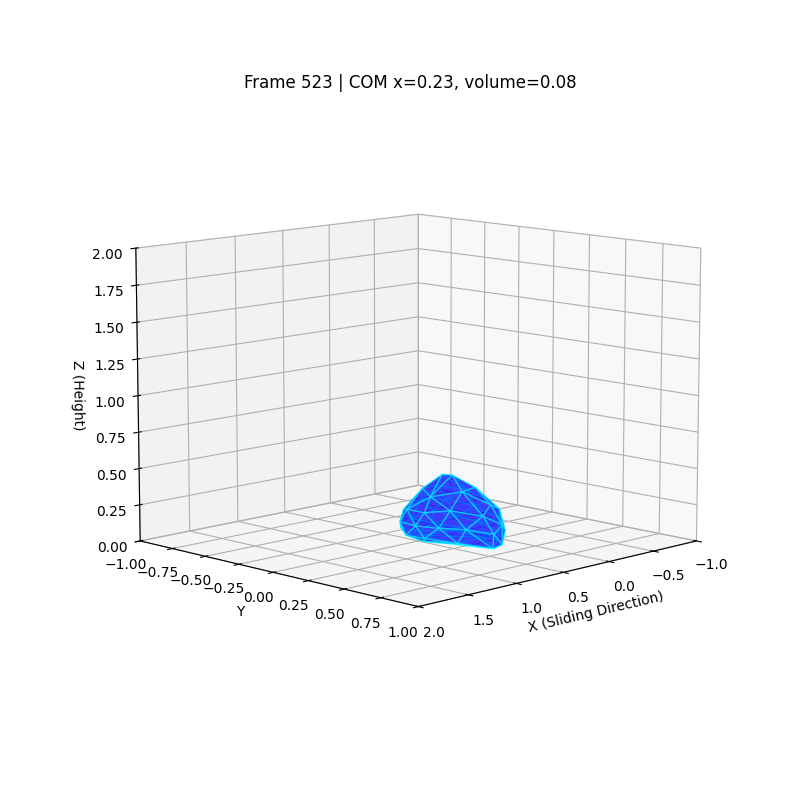

In [66]:
x, faces, neighbours = generate_polyhedron(n_vertices=100, radius=0.3)
v = np.zeros_like(x)
x += np.array([0.0, 0.0, 0.4], dtype=np.float32)  # Drop height
_, V_0 = compute_vertex_normals_and_volume(x, faces)

g = np.array([9.81, 0.0, -9.81])  # Tilted gravity for sliding effect
a = g.copy()  # Initialize acceleration to gravity

nu = 0.1  # mapped to eta in the function-based solver

# Simulation settings
dt = 0.016
sub_steps = 8
sub_dt = dt / sub_steps

# Rendering setup
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")
poly = Poly3DCollection(x[faces], alpha=0.5, edgecolor="cyan", facecolors="blue")
ax.add_collection3d(poly)
# sc = ax.scatter(x[:, 0], x[:, 1], x[:, 2], c="blue", s=20)

ax.set(
    xlim=(-2, 4),
    ylim=(-3, 3),
    zlim=(0, 4),
    xlabel="X (Sliding Direction)",
    ylabel="Y",
    zlabel="Z (Height)",
    title="Real-Time Interactive Water Droplets Simulator",
)

for frame in range(2000):
    # Explicit internal sub-stepping to maintain simulation stability
    for _ in range(sub_steps):
        a, v, x = update(
            a, v, x, 
            faces, neighbours, V_0,
            dt=sub_dt, 
            g=g,
            gamma=5000.0,  # higher tension to preserve bead shape
            mu=16.0,        # damping
            eta=8.0,      # Laplacian viscosity
            k_v=2000.0,
            rho=0.1,
            alpha=3.0,     # contact angle stiffness
            friction_coeff=0.2,
            damping_gain=1.6, # Apply new robust damping
            receding_angle=np.deg2rad(89.0),
            advancing_angle=np.deg2rad(91.0),
            # receding_angle=np.deg2rad(119.0),
            # advancing_angle=np.deg2rad(121.0),
            method="verlet",
        )
        
        # gamma=50.0, 
        #     mu=3.0, 
        #     eta=0.98, 
        #     k_v=2000.0, 
        #     friction_coeff=0.2,
        

# for frame in range(2000):
#     for _ in range(sub_steps):
#         v, x = step_simulation(
#             v, x, faces, neighbours, V_0,
#             dt=sub_dt, g=np.array([0.0, 0.0, -9.810]),
#             gamma=2000.0,  # higher tension to preserve bead shape
#             mu=16.0,        # numerically safer damping than very large explicit mu
#             eta=8.0,      # keep Laplacian viscosity in a stable/recommended range
#             k_v=2000.0,
#             rho=0.1,    # lower density to allow more visible deformation without extreme forces
#             alpha=3.0,     # contact angle stiffness
#             friction_coeff=0.1,
#             # contact_angles=(np.deg2rad(105.0), np.deg2rad(125.0)),
#             # contact_angles=(np.deg2rad(86.0), np.deg2rad(94.0)),
#             contact_angles=(np.deg2rad(59.0), np.deg2rad(61.0)),
#             volume_correction_mode="both",
#         )
        
        # v, x = step_simulation(
        #     v, x, faces, neighbours, V_0,
        #     dt=sub_dt, g=np.array([0.0, 0.0, -9.810]),
        #     gamma=2000.0,  # higher tension to preserve bead shape
        #     mu=16.0,        # numerically safer damping than very large explicit mu
        #     eta=6.0,      # keep Laplacian viscosity in a stable/recommended range
        #     k_v=2000.0,
        #     rho=0.1,    # lower density to allow more visible deformation without extreme forces
        #     alpha=0.2,     # contact angle stiffness
        #     friction_coeff=0.1,
        #     contact_angles=(np.deg2rad(105.0), np.deg2rad(125.0)),
        #     volume_correction_mode="both",
        # )

    # Update visual data
    # sc._offsets3d = (x[:, 0], x[:, 1], x[:, 2])
    poly.set_verts(x[faces])

    # Keep droplet in view as it slides
    center = x.mean(axis=0)
    ax.set_xlim(-1, 2)
    ax.set_ylim(-1, 1)
    ax.set_zlim(0.0, 2.0)
    _, volume = compute_vertex_normals_and_volume(x, faces)
    ax.set_title(f"Frame {frame} | COM x={center[0]:.2f}, volume={volume:.2f}")
    ax.view_init(elev=10, azim=45)

    # Notebook-friendly refresh
    display.clear_output(wait=True)
    display.display(fig)
    time.sleep(0.01)

plt.close(fig)